In [16]:
from langgraph.graph import StateGraph, START, END

from typing import TypedDict

In [27]:
#define state

class BMIState(TypedDict):
    weight_kg : float
    height_m : float
    bmi : float
    fitness : str

In [28]:
def calculate_bmi(state: BMIState) -> BMIState:
    bmi = state['weight_kg']/(state['height_m']**2)
    state['bmi'] = round(bmi,2)
    return state

In [29]:
def tell_fitness(state:BMIState) -> BMIState:
    bmi = state['bmi']
    if(bmi<18.5):
        state['fitness'] = 'underweight'
    elif(bmi<25):
        state['fitness'] = 'normal weight'
    else:
        state['fitness'] = 'overweight'
        
    return state

In [30]:
#define graph
graph = StateGraph(BMIState)

#add nodes to graph
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('tell_fitness', tell_fitness)

In [31]:
#add edges to graph
graph.add_edge(START, "calculate_bmi")
graph.add_edge("calculate_bmi", "tell_fitness")
graph.add_edge("tell_fitness",END)

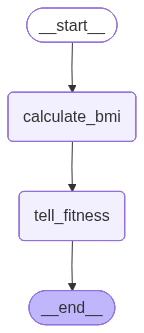

In [32]:
#compile the graph
graph.compile()

In [33]:
#execute the graph
workflow = graph.compile()
output_state = workflow.invoke({
    'weight_kg':72,
    'height_m':1.73
})
print(output_state)


{'weight_kg': 72, 'height_m': 1.73, 'bmi': 24.06, 'fitness': 'normal weight'}
